# CityMesh: real measurements behind the radio-link slide

This notebook downloads **two real, public datasets**, merges them into one table, and draws the graphs for the slide *"Can a sensor's message actually reach the gateway or tower?"*.

| | Dataset A (outdoor) | Dataset B (indoor) |
|---|---|---|
| Name | LoRaWAN Path Loss Measurements in an Urban Scenario | RSSI-Dataset |
| What | 930,753 LoRaWAN packets from 4 nodes, 2.1 to 8.3 km from the gateway, Medellín | RSSI readings for BLE, Wi-Fi, ZigBee and LoRaWAN in two offices, about 0.5 to 5.6 m |
| Paper | González-Palacio et al., *Data* 8(1), 2023, doi:10.3390/data8010004 | Sadowski and Spachos, *IEEE Access*, 2018, doi:10.1109/ACCESS.2018.2843325 |
| Source | github.com/magonzalezudem/MDPI_LoRaWAN_Dataset_With_Environmental_Variables | github.com/pspachos/RSSI-Dataset |

Cite both papers if you use the graphs.

In [1]:
import os, io, re, math, zipfile, glob, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RED, DARK, GREY, GREEN, BLUE = '#b30000', '#5a0000', '#9e9e9e', '#2e7d32', '#1f5fa8'
plt.rcParams.update({'font.size': 12, 'axes.spines.top': False, 'axes.spines.right': False})

## Step 1: download the two datasets (only the first time)

In [2]:
URL_A = ('https://raw.githubusercontent.com/magonzalezudem/'
         'MDPI_LoRaWAN_Dataset_With_Environmental_Variables/main/'
         'LoRaWAN%20Path%20Loss%20Measurement%20Campaign.zip')
URL_B = 'https://github.com/pspachos/RSSI-Dataset/archive/refs/heads/master.zip'

def fetch(url, folder):
    if os.path.isdir(folder):
        print(folder, 'already downloaded'); return
    print('downloading', folder, '...')
    data = urllib.request.urlopen(url).read()
    zipfile.ZipFile(io.BytesIO(data)).extractall(folder)
    print('  done:', round(len(data) / 1e6, 1), 'MB')

fetch(URL_A, 'dataset_A_urban_lorawan')
fetch(URL_B, 'dataset_B_indoor_rssi')

downloading dataset_A_urban_lorawan ...
  done: 20.4 MB
downloading dataset_B_indoor_rssi ...
  done: 3.2 MB


## Step 2: load dataset A (outdoor urban LoRaWAN)

In [3]:
file_a = glob.glob('dataset_A_urban_lorawan/**/*.csv', recursive=True)[0]
A = pd.read_csv(file_a)
print(len(A), 'rows')
A[['device_id', 'distance', 'sf', 'frame_length', 'rssi', 'snr', 'toa', 'experimental_pl']].head()

930753 rows


,device_id,distance,sf,frame_length,rssi,snr,toa,experimental_pl
0,EN1,2140,9,26,-72,7.8,0.205824,93.90644
1,EN1,2140,9,35,-77,6.5,0.246784,98.90644
2,EN1,2140,9,44,-73,6.2,0.287744,94.90644
3,EN1,2140,9,53,-77,6.0,0.328704,98.90644
4,EN1,2140,10,10,-73,7.0,0.288768,94.90644


## Step 3: load dataset B (indoor, four technologies)
Each file is named `<d>D<position>.txt`, where three transmitters A, B, C sit on a right-angle triangle with legs of d metres and the receiver is at position 1, 2 or 3. The true distance to each transmitter follows from that geometry.

In [4]:
def node_distance(d, pos, node):
    """Distance in metres from the receiver to node A, B or C. B is the right-angle corner."""
    xy = {'A': (0, d), 'B': (0, 0), 'C': (d, 0)}[node]
    rx = {1: (0, d / 2), 2: (d / 2, d / 2), 3: (d / 3, d / 3)}[pos]   # mid AB, mid AC, centroid
    return math.hypot(xy[0] - rx[0], xy[1] - rx[1])

rows = []
for path in glob.glob('dataset_B_indoor_rssi/**/Environment*/*/*D*.txt', recursive=True):
    env, tech, name = path.replace('\\', '/').split('/')[-3:]
    d, pos = int(name[0]), int(name[2])
    for line in open(path, errors='ignore'):
        m = re.match(r'\s*Node\s*([ABC])\s*:\s*(-?\d+)', line)
        if m:
            rows.append((env, tech, m.group(1), node_distance(d, pos, m.group(1)), int(m.group(2))))
B = pd.DataFrame(rows, columns=['office', 'technology', 'node', 'distance_m', 'rssi_dbm'])
print(len(B), 'rows')
B.groupby('technology')['rssi_dbm'].describe().round(1)

22695 rows


,count,mean,std,min,25%,50%,75%,max
technology,,,,,,,,
BLE,5418.0,-70.0,10.6,-107.0,-77.0,-70.0,-63.0,-46.0
LoRaWAN,5760.0,-31.0,4.6,-53.0,-35.0,-31.0,-27.0,-23.0
WiFi,5778.0,-51.2,5.9,-65.0,-55.8,-53.0,-47.0,-37.0
Zigbee,5739.0,-54.3,7.9,-73.0,-60.0,-56.0,-49.0,-33.0


## Step 4: merge the two datasets into one table
Both are brought to the same columns, then stacked with `pd.concat`.

In [5]:
A_std = pd.DataFrame({
    'dataset': 'A: urban LoRaWAN (Gonzalez-Palacio 2023)',
    'environment': 'Outdoor urban',
    'technology': 'LoRaWAN',
    'node': A['device_id'],
    'distance_m': A['distance'].astype(float),
    'rssi_dbm': A['rssi'].astype(float),
    'path_loss_db': A['experimental_pl'],
    'spreading_factor': A['sf'],
    'airtime_s': A['toa'],
})
B_std = pd.DataFrame({
    'dataset': 'B: indoor RSSI (Sadowski 2018)',
    'environment': 'Indoor office',
    'technology': B['technology'].replace({'Zigbee': 'ZigBee', 'WiFi': 'Wi-Fi'}),
    'node': B['office'] + '-' + B['node'],
    'distance_m': B['distance_m'],
    'rssi_dbm': B['rssi_dbm'].astype(float),
})
merged = pd.concat([A_std, B_std], ignore_index=True)
merged.to_csv('merged_signal_dataset.csv', index=False)
print(len(merged), 'rows in the merged dataset')
merged.groupby(['environment', 'technology']).agg(rows=('rssi_dbm', 'size'),
      min_distance_m=('distance_m', 'min'), max_distance_m=('distance_m', 'max'),
      mean_rssi_dbm=('rssi_dbm', 'mean')).round(1)

953448 rows in the merged dataset


rows  min_distance_m  max_distance_m  \
environment   technology                                           
Indoor office BLE           5418             0.5             5.6   
              LoRaWAN       5760             0.5             5.6   
              Wi-Fi         5778             0.5             5.6   
              ZigBee        5739             0.5             5.6   
Outdoor urban LoRaWAN     930753          2140.0          8260.0   

                          mean_rssi_dbm  
environment   technology                 
Indoor office BLE                 -70.0  
              LoRaWAN             -31.0  
              Wi-Fi               -51.2  
              ZigBee              -54.3  
Outdoor urban LoRaWAN             -83.1

## Graph 1: how much signal is lost? (path loss)
Mean received signal against distance, from half a metre indoors to 8 km outdoors. The line is the log-distance model from the slide, fitted to the outdoor path-loss measurements.

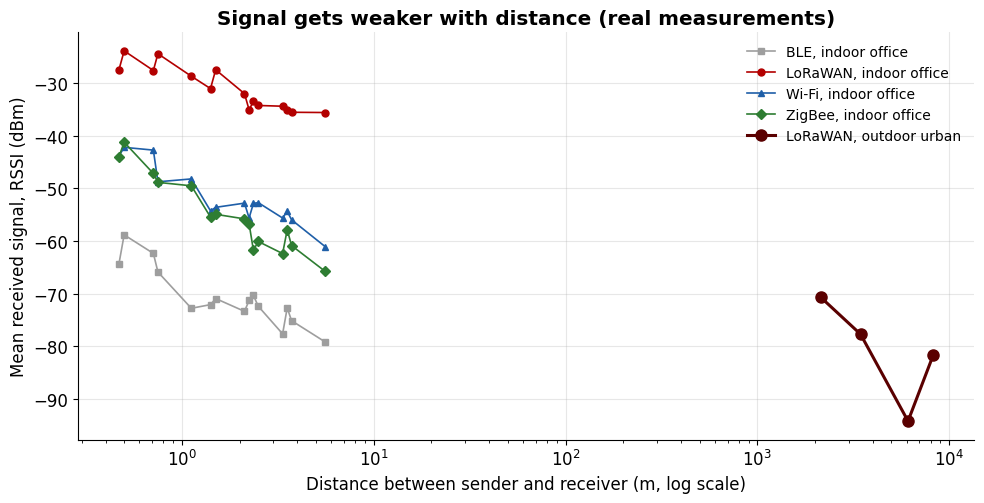

Outdoor fit: path-loss exponent n = 2.74, shadowing sigma = 2.5 dB


In [6]:
g = merged.assign(dist_bin=merged['distance_m'].round(2)).groupby(
        ['environment', 'technology', 'dist_bin'])['rssi_dbm'].mean().reset_index()

fig, ax = plt.subplots(figsize=(10, 5.2))
style = {('Indoor office', 'BLE'): (GREY, 's'), ('Indoor office', 'Wi-Fi'): (BLUE, '^'),
         ('Indoor office', 'ZigBee'): (GREEN, 'D'), ('Indoor office', 'LoRaWAN'): (RED, 'o'),
         ('Outdoor urban', 'LoRaWAN'): (DARK, 'o')}
for (env, tech), part in g.groupby(['environment', 'technology']):
    col, mk = style[(env, tech)]
    ax.plot(part['dist_bin'], part['rssi_dbm'], mk + '-', color=col, ms=8 if env == 'Outdoor urban' else 5,
            lw=2.2 if env == 'Outdoor urban' else 1.2, label=f'{tech}, {env.lower()}')
ax.set_xscale('log')
ax.set_xlabel('Distance between sender and receiver (m, log scale)')
ax.set_ylabel('Mean received signal, RSSI (dBm)')
ax.set_title('Signal gets weaker with distance (real measurements)', fontweight='bold')
ax.grid(alpha=0.3)
ax.legend(frameon=False, fontsize=10)
plt.tight_layout(); plt.savefig('graph1_signal_vs_distance.png', dpi=200); plt.show()

# fit the slide's equation PL = PL0 + 10 n log10(d) to the outdoor measurements
out = merged[merged['environment'] == 'Outdoor urban']
slope, intercept = np.polyfit(np.log10(out['distance_m']), out['path_loss_db'], 1)
resid = out['path_loss_db'] - (intercept + slope * np.log10(out['distance_m']))
print(f'Outdoor fit: path-loss exponent n = {slope / 10:.2f}, shadowing sigma = {resid.std():.1f} dB')

## Graph 2: is it still strong enough? (link budget)
Link margin = measured signal minus the weakest signal the receiver can still decode (its sensitivity). A positive margin means the message gets through.

Sensitivities are typical datasheet values, not measured here: LoRa −137 dBm (SF12), ZigBee −100 dBm, BLE −95 dBm, Wi-Fi −82 dBm.

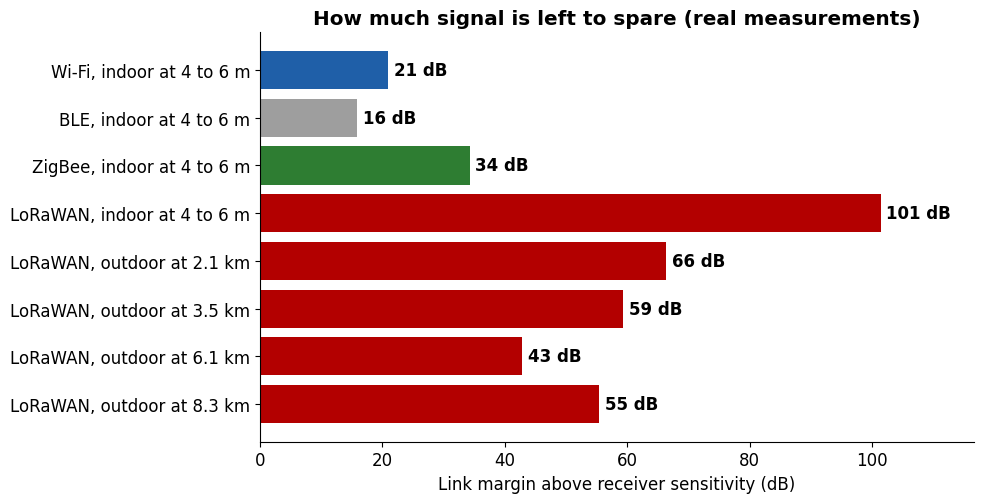

In [7]:
SENS = {'LoRaWAN': -137, 'ZigBee': -100, 'BLE': -95, 'Wi-Fi': -82}

indoor = merged[merged['environment'] == 'Indoor office']
far = indoor[indoor['distance_m'] >= 4]                       # the farthest indoor positions
bars = [(f'{t}, indoor at 4 to 6 m', far[far['technology'] == t]['rssi_dbm'].mean() - SENS[t], t)
        for t in ['Wi-Fi', 'BLE', 'ZigBee', 'LoRaWAN']]
for dist, part in out.groupby('distance_m'):
    bars.append((f'LoRaWAN, outdoor at {dist / 1000:.1f} km', part['rssi_dbm'].mean() - SENS['LoRaWAN'], 'LoRaWAN'))
labels, margins, techs = zip(*bars)
colors = [{'LoRaWAN': RED, 'ZigBee': GREEN, 'BLE': GREY, 'Wi-Fi': BLUE}[t] for t in techs]

fig, ax = plt.subplots(figsize=(10, 5.2))
b = ax.barh(labels, margins, color=colors)
ax.bar_label(b, fmt='%.0f dB', padding=4, fontweight='bold')
ax.set_xlim(0, max(margins) * 1.15)
ax.set_xlabel('Link margin above receiver sensitivity (dB)')
ax.set_title('How much signal is left to spare (real measurements)', fontweight='bold')
ax.invert_yaxis()
plt.tight_layout(); plt.savefig('graph2_link_margin.png', dpi=200); plt.show()

## Bonus graph 3: do messages collide? (LoRaWAN capacity)
The measured airtime per spreading factor from dataset A goes into the slide's collision equation, `PDR = exp(-2 N T_air / (T C))`, with one report every 30 minutes on 8 channels.

Measured mean airtime (s) by spreading factor:
spreading_factor
7.0     0.208
8.0     0.220
9.0     0.232
10.0    0.258
Name: airtime_s, dtype: float64


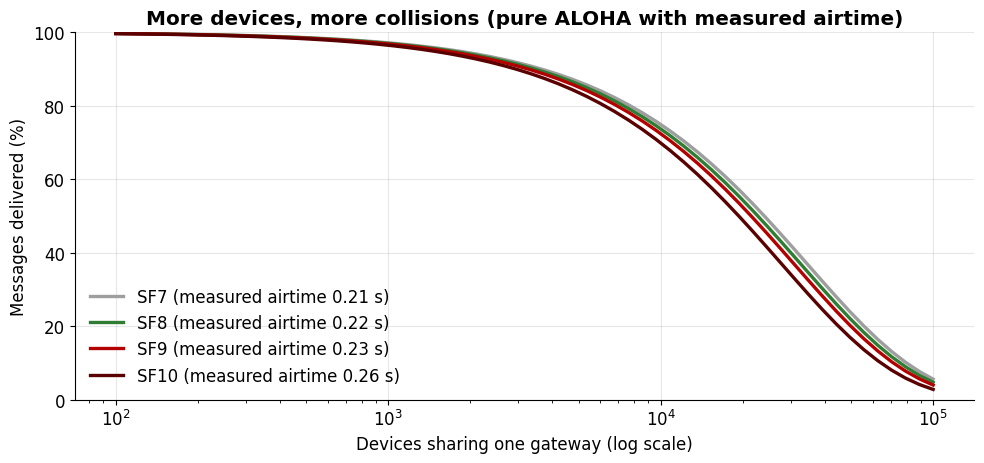

In [8]:
airtime = out.groupby('spreading_factor')['airtime_s'].mean()
print('Measured mean airtime (s) by spreading factor:'); print(airtime.round(3))

N = np.logspace(2, 5, 60)                 # devices sharing one gateway
T, C = 1800, 8
fig, ax = plt.subplots(figsize=(10, 4.8))
for sf, col in zip(airtime.index, [GREY, GREEN, RED, DARK]):
    ax.plot(N, 100 * np.exp(-2 * N * airtime[sf] / (T * C)), color=col, lw=2.4,
            label=f'SF{int(sf)} (measured airtime {airtime[sf]:.2f} s)')
ax.set_xscale('log'); ax.set_ylim(0, 100)
ax.set_xlabel('Devices sharing one gateway (log scale)')
ax.set_ylabel('Messages delivered (%)')
ax.set_title('More devices, more collisions (pure ALOHA with measured airtime)', fontweight='bold')
ax.grid(alpha=0.3); ax.legend(frameon=False)
plt.tight_layout(); plt.savefig('graph3_collisions.png', dpi=200); plt.show()